# Sale prices King County, prediction model

# Objectives

# Methodology

- The following libraries will be used during this notebook: 

In [69]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

# Data Overview

## 1. Data import

In [51]:
#Data importing 
df = pd.read_csv("../data/king_ country_ houses_aa.csv")

## 2. Data exploration

### Data description extracted from source: 

- id :- It is the unique numeric number assigned to each house being sold.
- date :- It is the date on which the house was sold out.
- price:- It is the price of house which we have to predict so this is our target variable and aprat from it are our features.
- bedrooms :- It determines number of bedrooms in a house.
- bathrooms :- It determines number of bathrooms in a bedroom of a house.
- sqft_living :- It is the measurement variable which determines the measurement of house in square foot.
- sqft_lot : It is also the measurement variable which determines square foot of the lot.
- floors: It determines total floors means levels of house.
- waterfront : This feature determines whether a house has a view to waterfront 0 means no 1 means yes.
- view : This feature determines whether a house has been viewed or not 0 means no 1 means yes.
- condition : It determines the overall condition of a house on a scale of 1 to 5.
- grade : It determines the overall grade given to the housing unit, based on King County grading system on a scale of 1 to 11
- sqft_above : It determines square footage of house apart from basement.
- sqft_basement : It determines square footage of the basement of the house.
- yr_built : It detrmines the date of building of the house.
- yr_renovated : It detrmines year of renovation of house.
- zipcode : It determines the zipcode of the location of the house.
- lat : It determines the latitude of the location of the house.
- long : It determines the longitude of the location of the house.
- sqft_living15 : Living room area in 2015(implies-- some renovations)
- sqft_lot15 : lotSize area in 2015(implies-- some renovations)

In [52]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

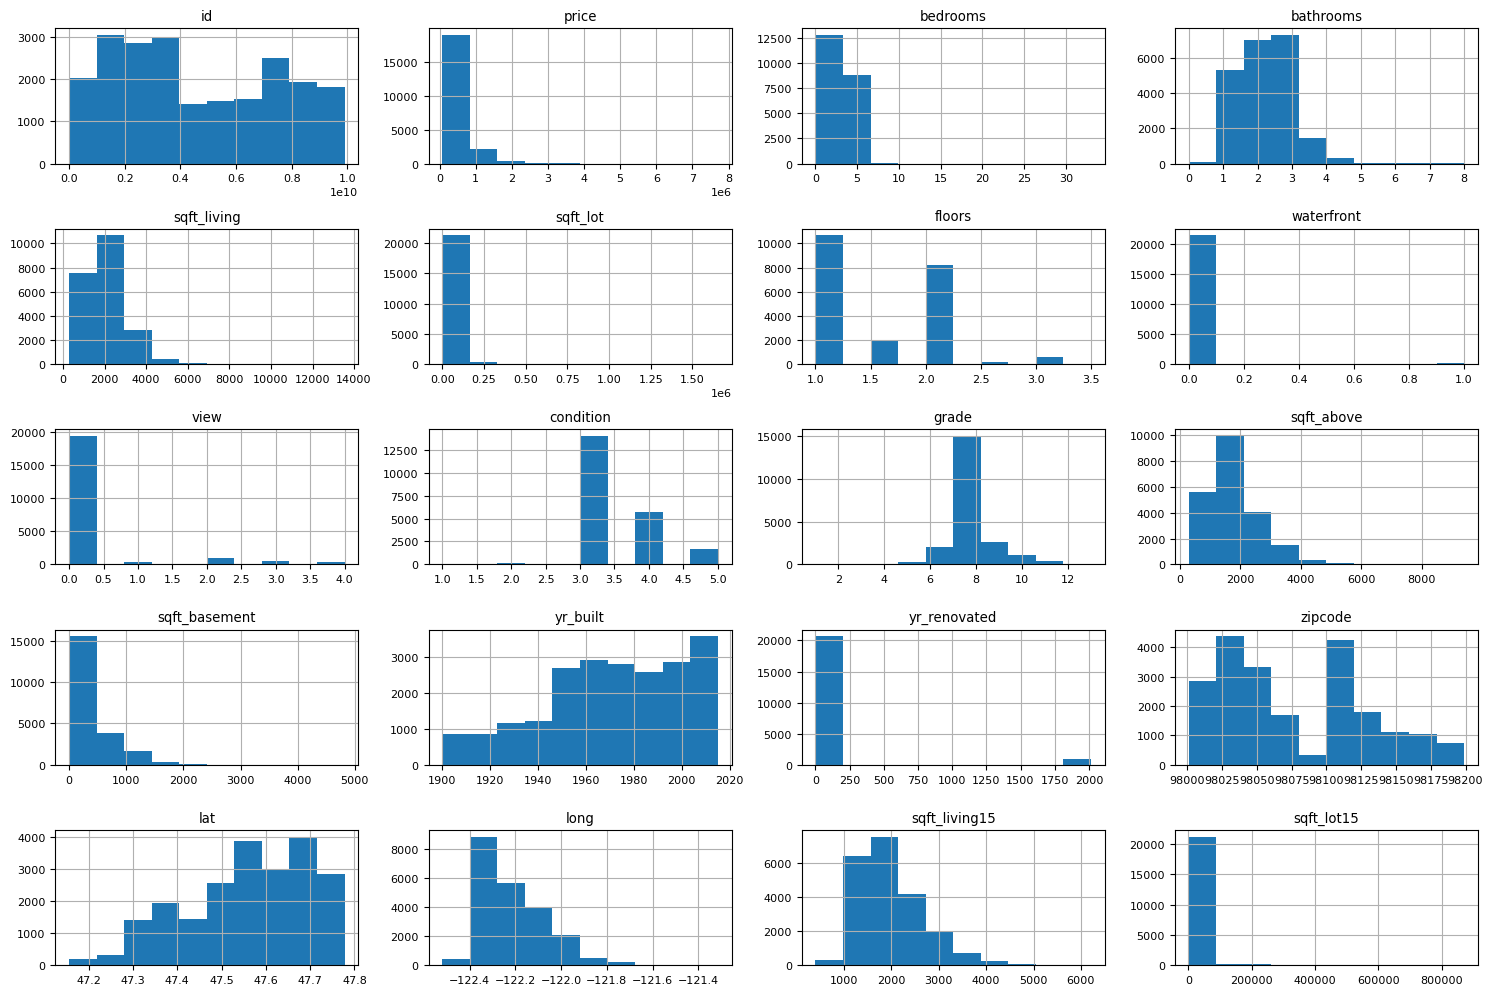

In [54]:
plt.rcParams.update({'font.size': 8})
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

In [55]:
df["price"].describe()

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

In [56]:
df.price.max()-df.price.min()

7625000.0

*Comments* 
- Data consists of both numerical and categorical types. 
- ID shows a uniform distribution, as it is an identifier for each sale, it is not expected to follow any trend.  
- Most variables are related to size, location and quality of the houses. 
- The price shows a big variance. 

## 3. Data cleaning

Checking for: 
1. Missing data 
2. Number of zeroes in each column 
3. Duplicated rows
4. Changing the target feature to the last column

In [57]:
# Missing data
df.isna().sum()


id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [58]:
# Percentage of 0 values in dataset
(df == 0).sum()/len(df)*100

id                0.000000
date              0.000000
price             0.000000
bedrooms          0.060149
bathrooms         0.046268
sqft_living       0.000000
sqft_lot          0.000000
floors            0.000000
waterfront       99.245824
view             90.172581
condition         0.000000
grade             0.000000
sqft_above        0.000000
sqft_basement    60.731967
yr_built          0.000000
yr_renovated     95.771064
zipcode           0.000000
lat               0.000000
long              0.000000
sqft_living15     0.000000
sqft_lot15        0.000000
dtype: float64

In [74]:
#Checking for duplicated rows
df_clean.duplicated().sum()

np.int64(0)

In [59]:
#Converting separating the date format into year,month and day.
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [60]:
# Moving target variable to the last column position for easier visualization in heatmaps.
df["price"] = df.pop("price")

In [61]:
#Only change required is to eliminate the concatenated date
df_clean = df.drop("date", axis = 1)

## 4. Split data categories as features vs target

In [62]:
#Selecting features and target variables
features = df_clean.drop("price", axis = 1)
target = df_clean["price"]

In [63]:
# Splitting features into numerical and categorical. 
df_clean.nunique()

id               21436
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
year                 2
month               12
day                 31
price             4028
dtype: int64

*Categorical variables* 
- Waterfront (takes values of 0 or 1)
- year (has only 2 values)
- zipcode: Represents a location
- (view, condition?)

In [64]:
# Taking continuous variables as numerical features. 
num_features= ['id', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15', 'year', 'month', 'day']

In [65]:
#Considering the classification above 
cat_features = ["waterfront","year","zipcode"]

## 5. Exploring Correlations in the data

C:\Users\nicol\AppData\Local\Temp\ipykernel_33056\1671008265.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = df_clean.corr().applymap(


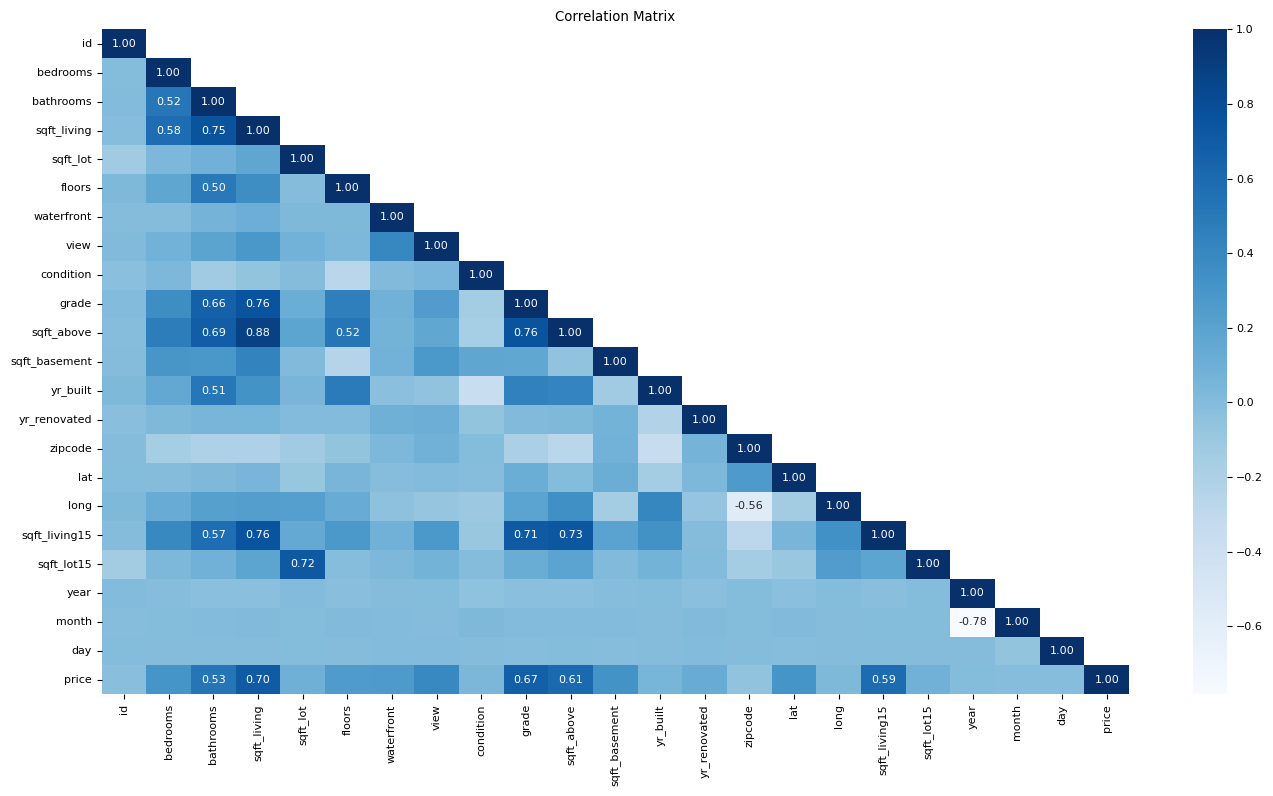

In [66]:
import numpy as np
plt.figure(figsize=(14,8))
#Annotations for those values above 0.5
annot_labels = df_clean.corr().applymap(
    lambda x: f"{x:.2f}" if abs(x) > 0.5 else ""
)

#Creating a mask for the upper triangle
mask = np.triu(np.ones_like(df_clean.corr(), dtype=bool),k=1) #k=1 will keep the ones in the diagonal
sns.heatmap(df_clean.corr(), annot=annot_labels,fmt='',mask=mask, cmap='Blues', xticklabels=df_clean.columns, yticklabels=df_clean.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

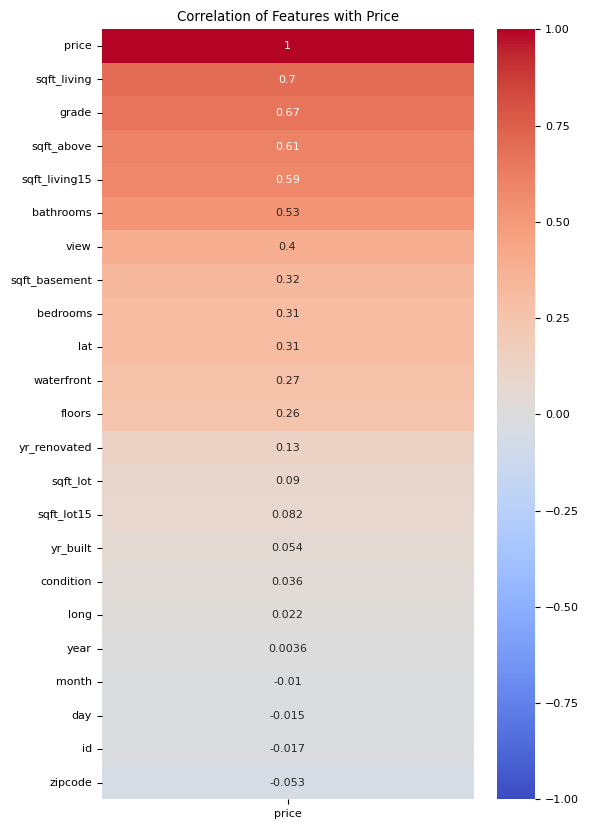

In [67]:
# Compute correlations with target
corr_with_price = df_clean.corr(numeric_only=True)[['price']].sort_values(by='price', ascending=False)

plt.figure(figsize=(6,10))
sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Correlation of Features with Price")
plt.show()

*Comments*

- Feature correlation: Highest correlation is observed between variables that refer to the sqft property and grade. 
- Target-Feature correlation: The features that correlate best to the target are those related to sqft of the property (sqft_above, sqft_living, sqft_living15 for those renovated in 2015), grade and number of bathrooms.
- The less correlation is found amongst zipcode, and id. Both parameters are not continuous, which is why the expected colinearity is low.  

## 6. Handle categorical variables. 

Considering year of renovation as a binary variable. 

In [ ]:
#Converting to 0 or 1 if renovated
df_clean["renovated"] = df_clean["yr_renovated"].apply(lambda x: 1 if x != 0 else x)


In [ ]:
#Dropping ID 
df_clean = df_clean.drop(["id", "lat","long","zipcode"], axis=1)


In [ ]:
df_clean

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,year,month,day,price,renovated
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,1340,5650,2014,10,13,221900.0,0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,1690,7639,2014,12,9,538000.0,1
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,2720,8062,2015,2,25,180000.0,0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,1360,5000,2014,12,9,604000.0,0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,1800,7503,2015,2,18,510000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,1530,1509,2014,5,21,360000.0,0
21609,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,1830,7200,2015,2,23,400000.0,0
21610,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,1020,2007,2014,6,23,402101.0,0
21611,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,1410,1287,2015,1,16,400000.0,0


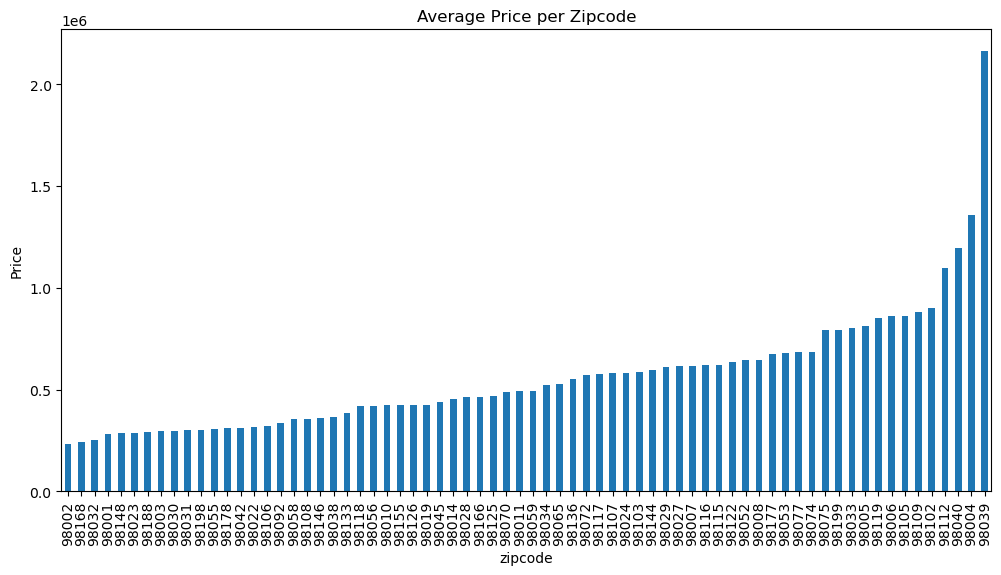

In [ ]:
avg_price = df.groupby('zipcode')['price'].mean().sort_values()

plt.figure(figsize=(12,6))
avg_price.plot(kind='bar')

plt.title("Average Price per Zipcode")
plt.ylabel("Price")
plt.show()

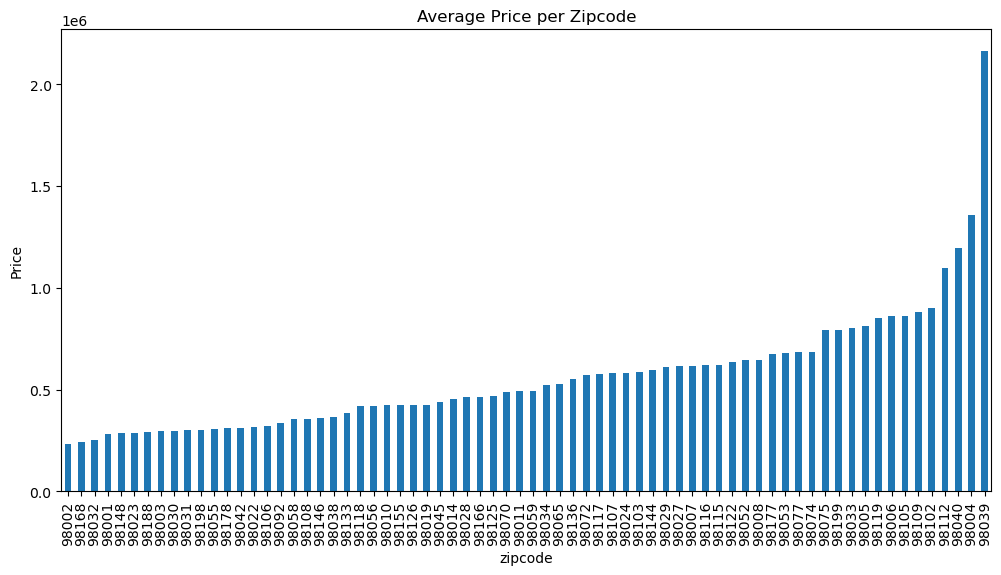

In [ ]:
avg_price = df.groupby('zipcode')['price'].mean().sort_values()

plt.figure(figsize=(12,6))
avg_price.plot(kind='bar')

plt.title("Average Price per Zipcode")
plt.ylabel("Price")
plt.show()

In [ ]:
zip_mean = df.groupby('zipcode')['price'].mean()
zip_category = pd.qcut(
    zip_mean,
    q = 3,
    labels = [1, 2, 3] # 1 lowest, 3 = highest
)
df['zipcode_category'] = df['zipcode'].map(zip_category)
df

In [ ]:
df['zipcode_category'].value_counts()

In [ ]:
avg_price = df.groupby('zipcode_category')['price'].mean().sort_values()

plt.figure(figsize=(12,6))
avg_price.plot(kind='bar')

plt.title("Average Price per Zipcode Category")
plt.ylabel("Price")
plt.show()

## 7. Training the Baseline model

### Linear Regression

In [70]:
X_num_features = df_clean[num_features]
target = df_clean["price"]
X_train, X_test, y_train, y_test = train_test_split(X_num_features, target, test_size= 0.2, random_state= 42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred

print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

129224.97770326545
0.6827258518596991


### KNN Regression

In [ ]:
# KNN numerical 

# Features & target
X = df_clean.drop(['price'], axis=1)
y = df_clean['price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline (ALL IN ONE BOX)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))


101043.12690261393
0.766425479693517


In [ ]:
# Train and test split 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size= 0.2, random_state= 42)

In [ ]:
# Baseline modeling Linear Regression 
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred = model.predict(X_test)
y_pred

array([ 460523.13645657,  737695.67105546, 1225230.40955363, ...,
        418780.25144894,  618614.68150915,  441337.10805686],
      shape=(4323,))

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score 
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

126912.34372601773
0.7027182400021401
